## Data Story: Der Takt des Radverkehrs – Trends und Muster erkennen

### 1. Einführung

In dieser Data Story arbeiten wir mit den **Raddauerzählstellen in München** (15-Minuten-Werte) und untersuchen, welche Muster sich im Zeitraum **2015 bis 2024** erkennen lassen. Dabei gehen wir unter anderem diesen Fragen nach:

- Wie viele Radfahrende wurden insgesamt und im Jahresmittel gezählt?
- Wie entwickelt sich die Nutzung über die Jahre?
- In welchen Monaten ist das Radfahren besonders stark ausgeprägt?
- Wo dominiert eher der Alltagsverkehr unter der Woche, wo eher das Freizeitverhalten am Wochenende?

Die Analyse nutzt **offene Daten** über [open.bydata](https://open.bydata.de), die dort von der Landeshauptstadt München veröffentlicht wurden.


**1.1 Dependencies installieren und importieren**


In [1]:
# %pip install requests pandas matplotlib folium


In [2]:
import html

import folium
import matplotlib.pyplot as plt
import pandas as pd
import requests


### 2. Daten finden und beziehen

**2.1 Datensatz im Portal**

- [open.bydata: Daten der Raddauerzählstellen München – Jahreszahlen](https://open.bydata.de/datasets/022a11ff-4dcb-4f03-b7dd-a6c94a094587)

**2.2 Hintergrund und Karte (Stadt München)**

- [Beschreibung der Raddauerzählstellen](https://opendata.muenchen.de/pages/raddauerzaehlstellen)
- [Datensatz der Raddauerzählstellen](https://opendata.muenchen.de/dataset/opendata_raddauerzaehlstellen)
- [Standorte der Raddauerzählstellen (GeoJSON)](https://geoportal.muenchen.de/geoserver/mor_wfs/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=mor_wfs:raddauerzaehlstellen&outputFormat=application/json)

Um die Zählstellen zu visualisieren, laden wir diese zunächst per **WFS GetFeature** als GeoJSON und zeigen sie als **interaktive Karte** in diesem Notebook. Wir nutzen dafür `folium` sowie die Attribute **`latitude`** und **`longitude`**.

Optional: [Geoportal Open Data (Karte im Browser)](https://geoportal.muenchen.de/portal/opendata/?MAPS={"center":[687866,5334348],"mode":"2D","zoom":4}&MENU={"main":{"currentComponent":"root"},"secondary":{"currentComponent":"root"}}&LAYERS=[{"id":"gsm:g_osm_mvg_style@WMTS","visibility":true},{"id":"gsm:g_stadtkarte","visibility":true},{"id":"gsm_wfs:vablock_stadtbezirk@WFS","visibility":true},{"id":"mor_wfs:raddauerzaehlstellen","visibility":true}]#)


In [3]:
STATIONS_WFS_GEOJSON = (
    "https://geoportal.muenchen.de/geoserver/mor_wfs/ows?"
    "service=WFS&version=1.0.0&request=GetFeature&"
    "typeName=mor_wfs:raddauerzaehlstellen&outputFormat=application/json"
)

# Retrieve station data from WFS
r = requests.get(STATIONS_WFS_GEOJSON, timeout=60)
r.raise_for_status()
station_fc = r.json()

# Read latitude and longitude of the stations
lats, lons = [], []
for feat in station_fc.get("features", []):
    p = feat.get("properties") or {}
    lat, lon = p.get("latitude"), p.get("longitude")
    if lat is not None and lon is not None:
        lats.append(float(lat))
        lons.append(float(lon))

# Create map
center = [sum(lats) / len(lats), sum(lons) / len(lons)] if lats else [48.14, 11.58]
m = folium.Map(location=center, zoom_start=12, control_scale=True)

# Place stations on the map
for feat in station_fc.get("features", []):
    p = feat.get("properties") or {}
    lat, lon = p.get("latitude"), p.get("longitude")
    if lat is None or lon is None:
        continue
    name = p.get("zaehlstelle") or "?"
    lang = p.get("zaehlstelle_lang") or ""
    popup_html = f"<b>{html.escape(str(name))}</b><br>{html.escape(str(lang))}"
    folium.CircleMarker(
        location=[float(lat), float(lon)],
        radius=9,
        color="#1f77b4",
        weight=2,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=str(name),
    ).add_to(m)

if lats:
    m.fit_bounds([[min(lats), min(lons)], [max(lats), max(lons)]], padding=(28, 28))

# Print map
m


**2.3 Daten für die Auswertung**

Für unsere Auswertung nutzen wir die **15-Minuten-Werte**, die je Jahr von der Landeshauptstadt München bereitgestellt werden.

### 3. Daten laden (2015–2024)

Um an die genauen Download-URLs pro Jahr zu kommen, nutzen wir die [**Search-API**](https://open.bydata.de/api/hub/search/) von open.bydata, wodurch wir diesen Schritt automatisieren können.


**3.1 Download-Links aus der open.bydata-API**


In [4]:
# Retrieve dataset from open.bydata Search API
api_url = (
    "https://open.bydata.de/api/hub/search/datasets/" # URL of the Search API
    "022a11ff-4dcb-4f03-b7dd-a6c94a094587" # ID of the dataset
)

# Function for automated retrieval of annual 15-minute distributions
def get_download_links(api_url: str) -> dict[int, str]:
    """Jahr -> access_url für 15-Minuten-Verteilungen (deutscher Titel)."""
    # Get dataset
    response = requests.get(api_url, timeout=60)
    response.raise_for_status()
    data = response.json()
    # Read distributions from dataset
    distributions = data['result']['distributions']
    # Collect download links for each year
    download_links: dict[int, str] = {}
    for dist in distributions:
        # Get distribution title
        title = dist['title']['de']
        # Extract year from title
        year_token = title.split()[-1]
        if not year_token.isdigit():
            continue
        year = int(year_token)
        if "15 Minuten Werte" not in title:
            # Ignore other distributions
            continue
        # Store download link for the year in dict
        download_links[year] = dist['access_url'][0]
    return download_links


download_links = get_download_links(api_url)
print(f"Gefundene Jahre (15-Min-Werte): {sorted(download_links.keys())}")


Gefundene Jahre (15-Min-Werte): [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


**3.2 CSVs einlesen und pro Jahr als DataFrame ablegen**


In [5]:
# Process a year's data and return as DataFrame
def process_year(year: int, url: str) -> pd.DataFrame:
    try:
        # Use download url from distribution
        df = pd.read_csv(url, low_memory=False)
        if "datum" in df.columns:
            df["datum"] = pd.to_datetime(df["datum"], format="%Y-%m-%d", errors="coerce")
        print(f"Jahr {year}: {len(df):,} Zeilen eingelesen.")
        return df
    except (pd.errors.ParserError, OSError, ValueError) as e:
        print(f"Fehler bei Jahr {year}: {e}")
        return pd.DataFrame()


YEAR_FROM, YEAR_TO = 2015, 2024
dataframes_per_year: dict[int, pd.DataFrame] = {}

# Iterate over years and process data
for year, url in sorted(download_links.items()):
    if YEAR_FROM <= year <= YEAR_TO:
        dataframes_per_year[year] = process_year(year, url)


Jahr 2015: 210,240 Zeilen eingelesen.
Jahr 2016: 210,816 Zeilen eingelesen.
Jahr 2017: 210,240 Zeilen eingelesen.
Jahr 2018: 210,232 Zeilen eingelesen.
Jahr 2019: 203,998 Zeilen eingelesen.
Jahr 2020: 210,816 Zeilen eingelesen.
Jahr 2021: 210,240 Zeilen eingelesen.
Jahr 2022: 210,240 Zeilen eingelesen.
Jahr 2023: 192,576 Zeilen eingelesen.
Jahr 2024: 132,672 Zeilen eingelesen.


**3.3 Datenstruktur prüfen**


In [6]:
example_year = next(iter(sorted(dataframes_per_year.keys())))

# Check data structure
dataframes_per_year[example_year].info()

# Show first few rows
dataframes_per_year[example_year].head()


<class 'pandas.DataFrame'>
RangeIndex: 210240 entries, 0 to 210239
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   datum          210240 non-null  datetime64[us]
 1   uhrzeit_start  210240 non-null  str           
 2   uhrzeit_ende   210240 non-null  str           
 3   zaehlstelle    210240 non-null  str           
 4   richtung_1     208704 non-null  float64       
 5   richtung_2     208704 non-null  float64       
 6   gesamt         208704 non-null  float64       
 7   kommentar      1536 non-null    str           
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 12.8 MB


,datum,uhrzeit_start,uhrzeit_ende,zaehlstelle,richtung_1,richtung_2,gesamt,kommentar
0,2015-01-01,00:00:00,00:15:00,Arnulf,0.0,0.0,0.0,NaN
1,2015-01-01,00:15:00,00:30:00,Arnulf,0.0,0.0,0.0,NaN
2,2015-01-01,00:30:00,00:45:00,Arnulf,0.0,0.0,0.0,NaN
3,2015-01-01,00:45:00,01:00:00,Arnulf,0.0,0.0,0.0,NaN
4,2015-01-01,01:00:00,01:15:00,Arnulf,0.0,0.0,0.0,NaN


### 4. Auswertungen

**4.1 Gesamtzahl der Radfahrenden (Summe aller Jahre im Zeitraum)**


Wie viele Radfahrende haben in Summe über alle Jahre hinweg die Radzählstellen passiert?

In [7]:
# Calculate total cyclists
total_cyclists = sum(df['gesamt'].dropna().sum() for df in dataframes_per_year.values())
print(
    f"Summe 'gesamt' {YEAR_FROM}–{YEAR_TO} (alle Zählstellen, alle Zeilen): "
    f"{total_cyclists:,.0f}"
)


Summe 'gesamt' 2015–2024 (alle Zählstellen, alle Zeilen): 39,979,546


**4.2 Durchschnittliche Summe pro Jahr**


Wie viele Radfahrende haben durchschnittlich pro Jahr in Summe die Radzählstellen passiert?

In [8]:
# Calculate average cyclists per year
n_years = len([df for df in dataframes_per_year.values() if not df.empty])
average_cyclists_per_year = total_cyclists / n_years if n_years else float('nan')
print(
    f"Durchschnittliche Jahressumme (über {n_years} Jahre): {average_cyclists_per_year:,.0f}"
)


Durchschnittliche Jahressumme (über 10 Jahre): 3,997,955


**4.3 Durchschnittlich gezählte Radfahrende pro Kalendertag**

Wie viele Radfahrende haben durchschnittlich pro Kalendertag die Radzählstellen passiert?

Wir zählen die **eindeutigen Kalendertage**, die in den importierten Zeitreihen vorkommen (über alle Stationen und Jahre hinweg).


In [9]:
date_series = pd.concat(
    [pd.to_datetime(df["datum"], format="%Y-%m-%d", errors="coerce") for df in dataframes_per_year.values() if not df.empty],
    ignore_index=True,
)
unique_dates = date_series.dropna().dt.normalize().unique()
total_days = len(unique_dates)
avg_cyclists_per_day = total_cyclists / total_days if total_days else float('nan')
print(f"Eindeutige Kalendertage im Datensatz: {total_days}")
print(f"Durchschnitt pro Tag (Summe / Tage): {avg_cyclists_per_day:,.2f}")


Eindeutige Kalendertage im Datensatz: 2922
Durchschnitt pro Tag (Summe / Tage): 13,682.25


**4.4 Jahresverlauf der Gesamtzählungen (alle Zählstellen)**


Wie viele Radfahrende haben im Laufe der Jahre die Radzählstellen passiert?

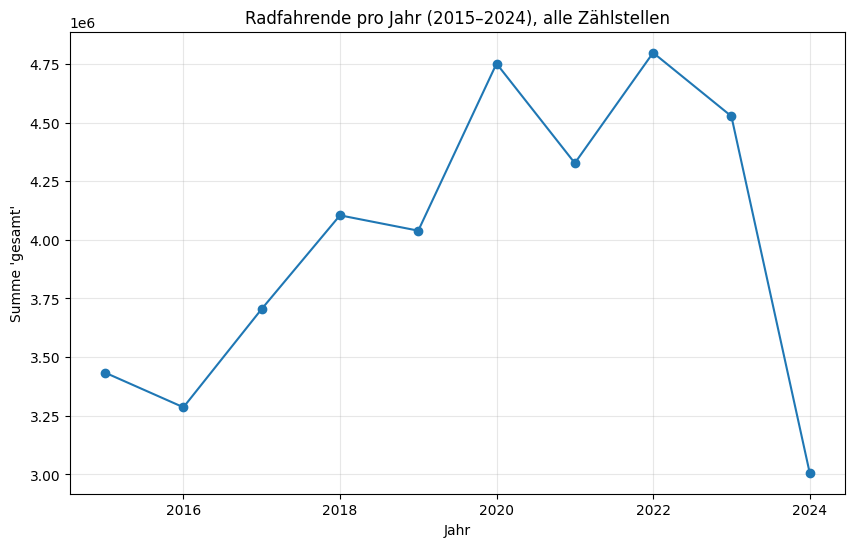

Jahressummen: {2015: np.float64(3433753.0), 2016: np.float64(3286145.0), 2017: np.int64(3705264), 2018: np.int64(4104533), 2019: np.float64(4039167.0), 2020: np.int64(4751460), 2021: np.float64(4327182.0), 2022: np.float64(4797843.0), 2023: np.float64(4527051.0), 2024: np.int64(3007148)}


In [10]:
# Calculate total cyclists per year
total_cyclists_per_year = {
    year: df['gesamt'].dropna().sum()
    for year, df in dataframes_per_year.items()
    if not df.empty
}
sorted_total_cyclists_per_year = dict(sorted(total_cyclists_per_year.items()))
years = list(sorted_total_cyclists_per_year.keys())
totals = list(sorted_total_cyclists_per_year.values())

# Plot total cyclists per year
plt.figure(figsize=(10, 6))
plt.plot(years, totals, marker="o")
plt.xlabel("Jahr")
plt.ylabel("Summe 'gesamt'")
plt.title(f"Radfahrende pro Jahr ({YEAR_FROM}–{YEAR_TO}), alle Zählstellen")
plt.grid(True, alpha=0.3)
plt.show()
print("Jahressummen:", sorted_total_cyclists_per_year)


**4.5 Monatsmuster: wann wird besonders viel geradelt?**

Wir aggregieren je Jahr die Summe von `gesamt` nach Kalendermonat und mitteln über die Jahre.

**Hinweis zum Datumsformat:** In den CSV-Dateien steht `datum` als **ISO-Datum** `YYYY-MM-DD` (z. B. `2015-01-01`). Für dieses Format darf **`dayfirst=True` nicht** verwendet werden — sonst werden viele Werte zu `NaT` oder in den falschen Monat geschoben, was u. a. einen künstlich hohen Januar erzeugen kann.


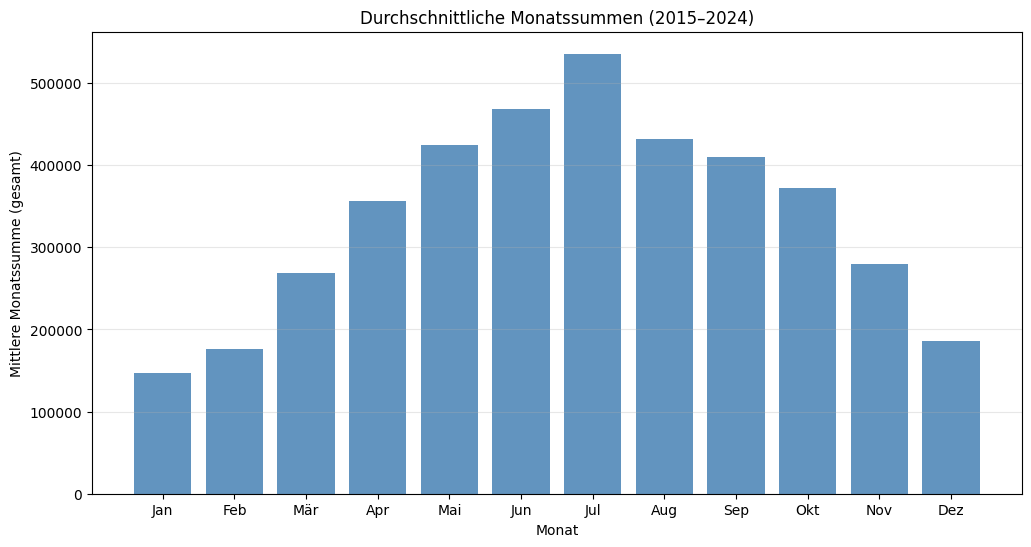

In [11]:
# Function to get monthly totals
def get_monthly_totals(df: pd.DataFrame) -> pd.Series:
    if df.empty:
        return pd.Series(dtype=float)
    d = df.copy()
    d["datum"] = pd.to_datetime(d["datum"], format="%Y-%m-%d", errors="coerce")
    return d.dropna(subset=["datum"]).groupby(d["datum"].dt.month)["gesamt"].sum()

# Get monthly totals for each year
monthly_totals_per_year = {
    year: get_monthly_totals(df) for year, df in dataframes_per_year.items() if not df.empty
}

# Combine monthly totals into a DataFrame
combined_monthly_totals = pd.DataFrame(monthly_totals_per_year).sort_index()
average_monthly_totals = combined_monthly_totals.mean(axis=1)

# Plot monthly totals
plt.figure(figsize=(12, 6))
plt.bar(average_monthly_totals.index, average_monthly_totals.values, color="steelblue", alpha=0.85)
plt.xlabel("Monat")
plt.ylabel("Mittlere Monatssumme (gesamt)")
plt.title(f"Durchschnittliche Monatssummen ({YEAR_FROM}–{YEAR_TO})")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun", "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"],
)
plt.grid(True, axis="y", alpha=0.3)
plt.show()


<ins>Raum für weitere Analyse und Interpretation</ins>

- Spiegelt das Maximum den Sommer, oder spielen auch Großveranstaltungen / Semesterferien eine Rolle?
- Wie sähe der Vergleich aus, wenn man nur einzelne Zählstellen oder Richtungen betrachten würde?


**4.6 Werktag vs. Wochenende nach Zählstelle**

Wir summieren `richtung_1` und `richtung_2` pro Zeile und vergleichen die aufsummierten Werte je Zählstelle für **Montag–Freitag** und **Samstag–Sonntag** über alle Jahre im Zeitraum.


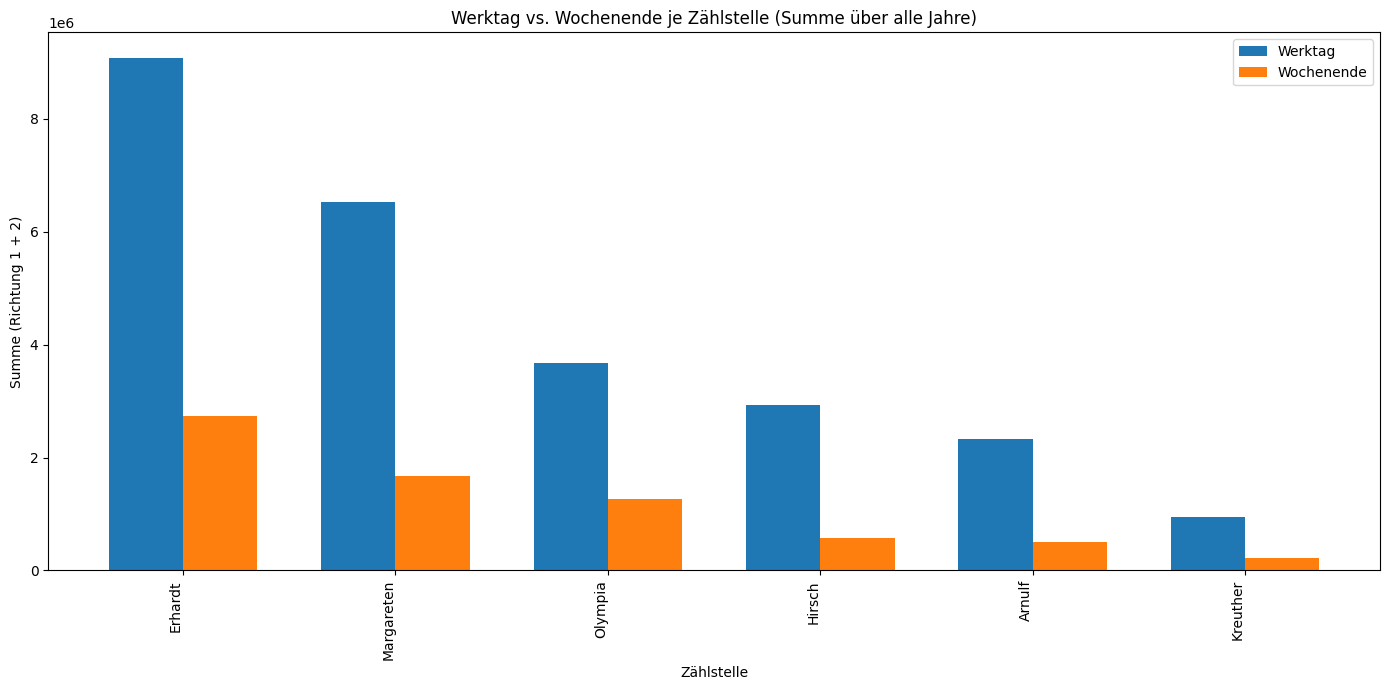

In [12]:
# Preprocess DataFrame for weekday/weekend comparison
def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["datum"] = pd.to_datetime(out["datum"], format="%Y-%m-%d", errors="coerce")
    out["richtung_1"] = pd.to_numeric(out["richtung_1"], errors="coerce")
    out["richtung_2"] = pd.to_numeric(out["richtung_2"], errors="coerce")
    out["gesamt"] = pd.to_numeric(out["gesamt"], errors="coerce")
    return out

# Preprocess dataframes for each year
dataframes_per_year = {y: preprocess_df(df) for y, df in dataframes_per_year.items()}

# Function to get weekday/weekend totals
def get_weekday_weekend_totals(df: pd.DataFrame):
    if df.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    d = df.copy()
    d["weekday"] = d["datum"].dt.dayofweek
    d["total"] = d["richtung_1"].fillna(0) + d["richtung_2"].fillna(0)
    weekday_totals = d.loc[d["weekday"] < 5].groupby("zaehlstelle")["total"].sum()
    weekend_totals = d.loc[d["weekday"] >= 5].groupby("zaehlstelle")["total"].sum()
    return weekday_totals, weekend_totals

# Initialize accumulator dicts
weekday_acc: dict[str, float] = {}
weekend_acc: dict[str, float] = {}

# Iterate over years and process data
for _year, df in dataframes_per_year.items():
    wd, we = get_weekday_weekend_totals(df)
    for name, total in wd.items():
        weekday_acc[name] = weekday_acc.get(name, 0) + float(total)
    for name, total in we.items():
        weekend_acc[name] = weekend_acc.get(name, 0) + float(total)

# Create series for plotting
weekday_totals_series = pd.Series(weekday_acc, dtype=float).sort_values(ascending=False)
weekend_totals_series = pd.Series(weekend_acc, dtype=float).reindex(
    weekday_totals_series.index
).fillna(0)

# Plot comparison
plt.figure(figsize=(14, 7))
bar_width = 0.35
index = range(len(weekday_totals_series))
plt.bar([i - bar_width / 2 for i in index], weekday_totals_series.values, bar_width, label="Werktag")
plt.bar([i + bar_width / 2 for i in index], weekend_totals_series.values, bar_width, label="Wochenende")
plt.xlabel("Zählstelle")
plt.ylabel("Summe (Richtung 1 + 2)")
plt.title("Werktag vs. Wochenende je Zählstelle (Summe über alle Jahre)")
plt.xticks([i for i in index], weekday_totals_series.index, rotation=90, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


### 5. Zusammenfassung und Ausblick

In dieser Data Story haben wir Münchner **Raddauerzähldaten** bezogen, die Daten für **2020–2024** eingelesen und Kennzahlen sowie einfache Visualisierungen erstellt: Gesamt- und Jahreswerte, Tagesmittel über Kalendertage, Jahrestrend, Monatsmittel sowie einen **Werktag/Wochenende-Vergleich** je Zählstelle.

**Nächste Schritte und weitere Analyseideen**

- Vergleich mit anderen Städten in Bayern, z. B. [Würzburg](https://open.bydata.de/datasets/fahrradzaehlung-tagesdaten-alle-zaehlstationen-wuerzburg~~2) oder [Augsburg](https://augsburg.bydata.de/datasets/radza-hlstationen-in-augsburg-1)
- Einfluss von Wetter, Ferien und Feiertagen
- Vorhersagemodelle für die erwartete Radfrequenz
- Abgleich mit anderen Verkehrsarten innerhalb der Stadtgrenzen
